## Тест

In [1]:
# import osmnx as ox
import pandas as pd
import geopandas as gpd
import networkx as nx
import numpy as np
import warnings
import sys
import os
warnings.filterwarnings("ignore")
sys.stderr = open(os.devnull, 'w')

# local crs
local_crs = 32636


from popframe.models.region import Region

region_model = Region.from_pickle('data/__popframe_model_cache__/3138.pkl')
# grid = gpd.read_file('/Users/mvin/Code/PopFrame/examples/data/level_3.geojson', engine="pyogrio")
# grid

In [2]:
import requests
import geopandas as gpd

def fetch_hexagons(
    territory_id: int,
    centers_only: bool = False,
    base_url: str = 'https://urban-api.idu.kanootoko.org/api/v1/territory/{territory_id}/hexagons'
) -> gpd.GeoDataFrame:
    """
    Запрос гексагонов для заданного territory_id и возвращает их в виде GeoDataFrame.

    :param territory_id: ID территории
    :param centers_only: если True — вернуть только центральные точки гексагонов
    :param base_url: шаблон URL с {territory_id}
    :return: GeoDataFrame с колонками geometry, hexagon_id и свойствами
    """
    # Подставляем ID в URL
    url = base_url.format(territory_id=territory_id)
    params = {
        'centers_only': centers_only
    }

    # Выполняем запрос
    response = requests.get(url, params=params)
    response.raise_for_status()  # вызовет исключение, если код != 200

    # Парсим GeoJSON
    geojson = response.json()
    features = geojson.get('features', [])

    # Строим GeoDataFrame
    # from_features автоматически извлечёт geometry и все свойства
    gdf = gpd.GeoDataFrame.from_features(features)
    # Устанавливаем CRS (WGS84)
    gdf = gdf.set_crs(epsg=4326)

    return gdf

territory_id = 3138  # ID территории для Санкт-Петербурга
gdf_hex = fetch_hexagons(territory_id, centers_only=False)
gdf_hex

,geometry,hexagon_id,properties
0,"POLYGON ((30.06574 59.6709, 30.07379 59.67194,...",157558,{}
1,"POLYGON ((30.0877 60.08939, 30.09047 60.09382,...",157559,{}
2,"POLYGON ((30.37948 59.7927, 30.38759 59.79372,...",157560,{}
3,"POLYGON ((30.66727 59.76362, 30.66198 59.76704...",157561,{}
4,"POLYGON ((30.24918 60.02467, 30.25198 60.0291,...",157562,{}
...,...,...,...
2529,"POLYGON ((30.45791 60.02272, 30.46608 60.02376...",160087,{}
2530,"POLYGON ((30.23231 59.84322, 30.23764 59.83983...",160088,{}
2531,"POLYGON ((29.50097 60.20315, 29.49286 60.20206...",160089,{}
2532,"POLYGON ((30.74536 59.757, 30.74007 59.76043, ...",160090,{}


In [3]:
import requests
import geopandas as gpd

def fetch_mo(
    territory_id: int,
    centers_only: bool = False,
    base_url: str = 'https://urban-api.idu.kanootoko.org/api/v1/territory/indicator_values'
) -> gpd.GeoDataFrame:
    """
    Запрос гексагонов для заданного territory_id и возвращает их в виде GeoDataFrame.

    :param territory_id: ID территории
    :param centers_only: если True — вернуть только центральные точки гексагонов
    :param base_url: шаблон URL с {territory_id}
    :return: GeoDataFrame с колонками geometry, hexagon_id и свойствами
    """
    # Подставляем ID в URL
    url = base_url.format(territory_id=territory_id)
    params = {
        'parent_id': territory_id,  # ID родительской территории (1 для МО)
        'indicator_ids' : 1
    }

    # Выполняем запрос
    response = requests.get(url, params=params)
    response.raise_for_status()  # вызовет исключение, если код != 200

    # Парсим GeoJSON
    geojson = response.json()
    features = geojson.get('features', [])

    # Строим GeoDataFrame
    # from_features автоматически извлечёт geometry и все свойства
    gdf = gpd.GeoDataFrame.from_features(features)
    # Устанавливаем CRS (WGS84)
    gdf = gdf.set_crs(epsg=4326)

    return gdf

territory_id = 3138  # ID территории для Санкт-Петербурга
gdf_mo = fetch_mo(territory_id, centers_only=False)
gdf_mo['population'] = gdf_mo['indicators'].apply(lambda lst: lst[0].get('value'))


gdf_mo

,geometry,territory_id,name,indicators,population
0,"MULTIPOLYGON (((30.25023 59.90129, 30.25112 59...",3153,Адмиралтейский район,"[{'name_full': 'Численность населения', 'measu...",155981.0
1,"MULTIPOLYGON (((30.17787 59.94437, 30.1779 59....",3145,Василеостровский район,"[{'name_full': 'Численность населения', 'measu...",206680.0
2,"MULTIPOLYGON (((30.07078 60.09625, 30.07421 60...",3144,Выборгский район,"[{'name_full': 'Численность населения', 'measu...",541590.0
3,"MULTIPOLYGON (((30.34398 59.97727, 30.34399 59...",3152,Калининский район,"[{'name_full': 'Численность населения', 'measu...",536794.0
4,"MULTIPOLYGON (((30.16152 59.87428, 30.16152 59...",3151,Кировский район,"[{'name_full': 'Численность населения', 'measu...",335774.0
5,"MULTIPOLYGON (((30.43875 59.82757, 30.44219 59...",3156,Колпинский район,"[{'name_full': 'Численность населения', 'measu...",186169.0
6,"MULTIPOLYGON (((30.39428 59.92902, 30.39591 59...",3150,Красногвардейский район,"[{'name_full': 'Численность населения', 'measu...",366971.0
7,"MULTIPOLYGON (((30.03496 59.71785, 30.04047 59...",3155,Красносельский район,"[{'name_full': 'Численность населения', 'measu...",431546.0
8,"MULTIPOLYGON (((29.54157 60.04248, 29.54184 60...",3141,Кронштадтский район,"[{'name_full': 'Численность населения', 'measu...",44414.0
9,"MULTIPOLYGON (((29.42576 60.19074, 29.42719 60...",3140,Курортный район,"[{'name_full': 'Численность населения', 'measu...",83491.0


In [4]:
import pandas as pd
all_gdfs = []

# 2. Перебираем все territory_id из уже имеющегося gdf_mo:
for parent_tid in gdf_mo['territory_id']:
    # вызываем вашу функцию fetch_mo для каждого района:
    child_gdf = fetch_mo(parent_tid, centers_only=False)
    
    # При желании можно сохранить «родительский» ID (т. е. ID района из gdf_mo),
    # чтобы потом понимать, к какому району относится каждая запись:
    child_gdf['parent_territory_id'] = parent_tid
    
    # При необходимости можно добавить и название «родительского» района:
    # например, найдём строку в gdf_mo с данным parent_tid и вытащим её name:
    parent_name = gdf_mo.loc[gdf_mo['territory_id'] == parent_tid, 'name'].iloc[0]
    child_gdf['parent_name'] = parent_name
    
    # Добавляем полученный GeoDataFrame в список:
    all_gdfs.append(child_gdf)

# 3. После цикла объединяем все GeoDataFrame в один:
#    ignore_index=True — чтобы сбросить индексы и получить «плоскую» таблицу.
combined_gdf = pd.concat(all_gdfs, ignore_index=True)
combined_gdf['population'] = combined_gdf['indicators'].apply(lambda lst: lst[0].get('value'))
combined_gdf


,geometry,territory_id,name,indicators,parent_territory_id,parent_name,population
0,"MULTIPOLYGON (((30.2818 59.93306, 30.28272 59....",3249,Адмиралтейский округ,"[{'name_full': 'Численность населения', 'measu...",3153,Адмиралтейский район,24189.0
1,"MULTIPOLYGON (((30.25023 59.90129, 30.25112 59...",3252,Екатерингофский округ,"[{'name_full': 'Численность населения', 'measu...",3153,Адмиралтейский район,21890.0
2,"MULTIPOLYGON (((30.29074 59.90313, 30.2909 59....",3251,округ Измайловское,"[{'name_full': 'Численность населения', 'measu...",3153,Адмиралтейский район,32807.0
3,"MULTIPOLYGON (((30.26049 59.91726, 30.26152 59...",3253,округ Коломна,"[{'name_full': 'Численность населения', 'measu...",3153,Адмиралтейский район,34026.0
4,"MULTIPOLYGON (((30.31777 59.9217, 30.31781 59....",3250,округ Семеновский,"[{'name_full': 'Численность населения', 'measu...",3153,Адмиралтейский район,22414.0
...,...,...,...,...,...,...,...
136,"MULTIPOLYGON (((30.30827 59.94106, 30.30908 59...",3169,Дворцовый округ,"[{'name_full': 'Численность населения', 'measu...",3143,Центральный район,7348.0
137,"MULTIPOLYGON (((30.33489 59.95015, 30.33642 59...",3166,Литейный округ,"[{'name_full': 'Численность населения', 'measu...",3143,Центральный район,40151.0
138,"MULTIPOLYGON (((30.31013 59.93647, 30.31023 59...",3165,округ № 78,"[{'name_full': 'Численность населения', 'measu...",3143,Центральный район,9085.0
139,"MULTIPOLYGON (((30.35063 59.91524, 30.35178 59...",3168,округ Лиговка-Ямская,"[{'name_full': 'Численность населения', 'measu...",3143,Центральный район,19563.0


In [5]:
from popframe.method.city_evaluation import CityPopulationScorer

scorer = CityPopulationScorer(combined_gdf, gdf_hex)


output_list = scorer.run()
scores_df = pd.DataFrame(output_list)
gdf_hex['score'] = scores_df['score']
gdf_hex

,geometry,hexagon_id,properties,score
0,"POLYGON ((30.06574 59.6709, 30.07379 59.67194,...",157558,{},2.0
1,"POLYGON ((30.0877 60.08939, 30.09047 60.09382,...",157559,{},1.0
2,"POLYGON ((30.37948 59.7927, 30.38759 59.79372,...",157560,{},3.0
3,"POLYGON ((30.66727 59.76362, 30.66198 59.76704...",157561,{},3.0
4,"POLYGON ((30.24918 60.02467, 30.25198 60.0291,...",157562,{},3.0
...,...,...,...,...
2529,"POLYGON ((30.45791 60.02272, 30.46608 60.02376...",160087,{},2.0
2530,"POLYGON ((30.23231 59.84322, 30.23764 59.83983...",160088,{},4.0
2531,"POLYGON ((29.50097 60.20315, 29.49286 60.20206...",160089,{},1.0
2532,"POLYGON ((30.74536 59.757, 30.74007 59.76043, ...",160090,{},3.0


In [6]:
scores_df

,hexagon_id,project,average_population_density,total_population,score,interpretation
0,157558,None,774.7,58652.0,2.0,Территория отличается относительно низкой числ...
1,157559,None,43.9,6021.0,1.0,Территория имеет низкиие показателяи численнос...
2,157560,None,318.5,132978.0,3.0,Территория имеет средние показатели численност...
3,157561,None,631.2,143914.0,3.0,Территория имеет средние показатели численност...
4,157562,None,2387.6,114257.0,3.0,Территория имеет средние показатели численност...
...,...,...,...,...,...,...
2529,160087,None,904.0,75180.0,2.0,Территория отличается относительно низкой числ...
2530,160088,None,4223.5,71589.0,4.0,Территория имеет высокие показатели численност...
2531,160089,None,33.4,1668.0,1.0,Территория имеет низкиие показателяи численнос...
2532,160090,None,631.2,143914.0,3.0,Территория имеет средние показатели численност...


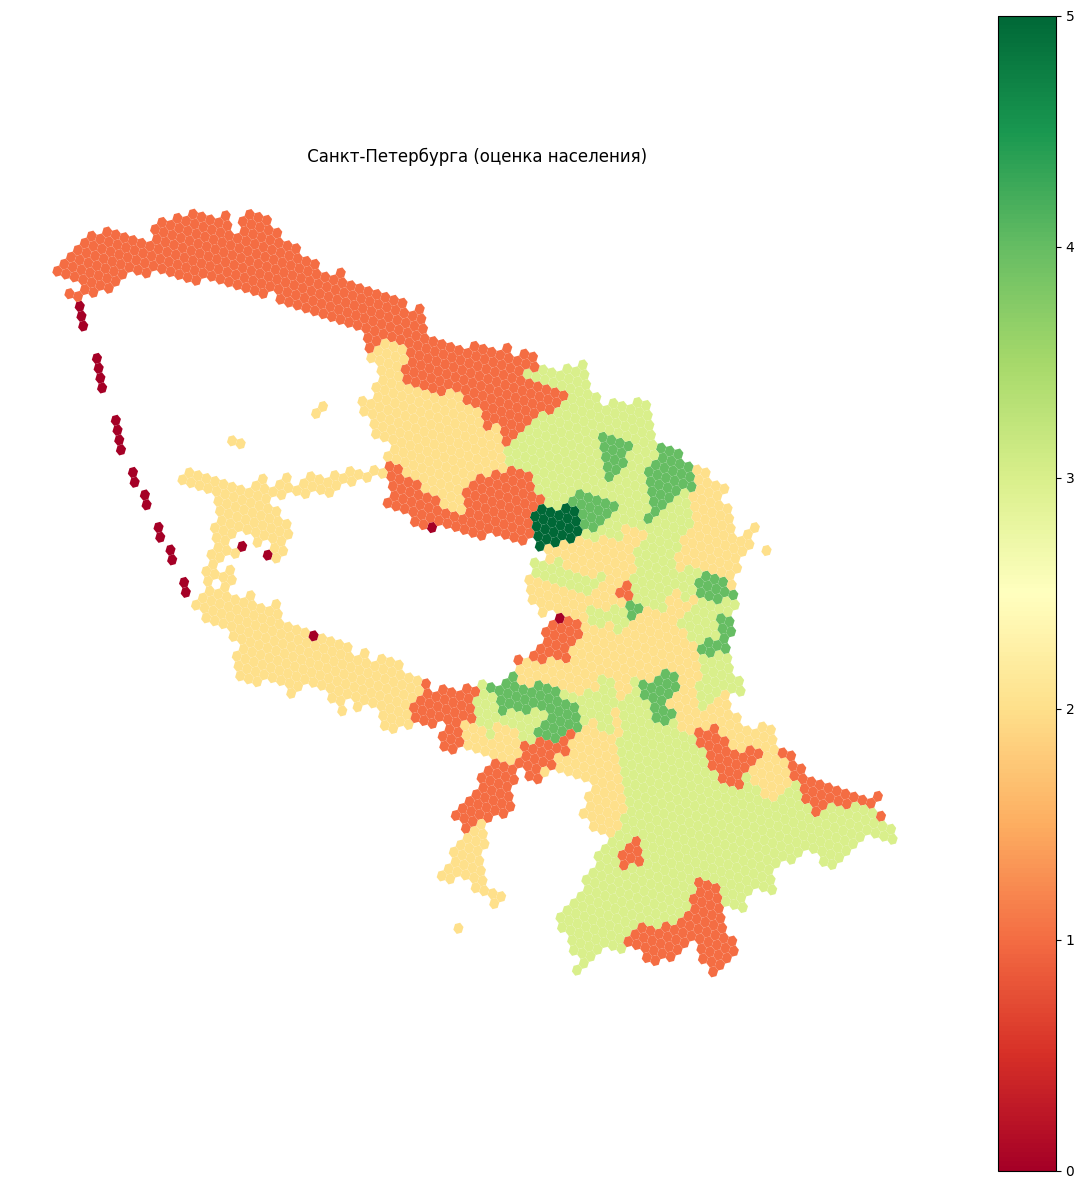

In [7]:
import matplotlib.pyplot as plt
gdf_hex.plot(
    column='score',
    legend=True,
    figsize=(15,15),
    cmap='RdYlGn'
).set_axis_off()
plt.title(' Санкт-Петербурга (оценка населения)')

plt.show()

## Население

In [8]:
from popframe.method.territory_evaluation import TerritoryEvaluation

evaluation = TerritoryEvaluation(region=region_model)

results = evaluation.population_criterion(territories_gdf=gdf_hex)
scores_df = pd.DataFrame(results)
scores_df

,project,average_population_density,total_population,score,interpretation
0,None,42.7,58652,4.0,Территория имеет хорошие показатели численност...
1,None,128.5,176684,5.0,Территория с высокими показателями численности...
2,None,120.5,165470,5.0,Территория с высокими показателями численности...
3,None,134.0,184079,5.0,Территория с высокими показателями численности...
4,None,81.6,112176,5.0,Территория с высокими показателями численности...
...,...,...,...,...,...
2529,None,0.0,0,0.0,Территория имеет нулевые показатели численност...
2530,None,0.0,0,0.0,Территория имеет нулевые показатели численност...
2531,None,2.6,3623,2.0,Территория имеет умеренные показатели численно...
2532,None,114.1,156766,5.0,Территория с высокими показателями численности...


In [9]:
gdf_hex['score'] = scores_df['score']
gdf_hex

,geometry,hexagon_id,properties,score
0,"POLYGON ((30.06574 59.6709, 30.07379 59.67194,...",157558,{},4.0
1,"POLYGON ((30.0877 60.08939, 30.09047 60.09382,...",157559,{},5.0
2,"POLYGON ((30.37948 59.7927, 30.38759 59.79372,...",157560,{},5.0
3,"POLYGON ((30.66727 59.76362, 30.66198 59.76704...",157561,{},5.0
4,"POLYGON ((30.24918 60.02467, 30.25198 60.0291,...",157562,{},5.0
...,...,...,...,...
2529,"POLYGON ((30.45791 60.02272, 30.46608 60.02376...",160087,{},0.0
2530,"POLYGON ((30.23231 59.84322, 30.23764 59.83983...",160088,{},0.0
2531,"POLYGON ((29.50097 60.20315, 29.49286 60.20206...",160089,{},2.0
2532,"POLYGON ((30.74536 59.757, 30.74007 59.76043, ...",160090,{},5.0


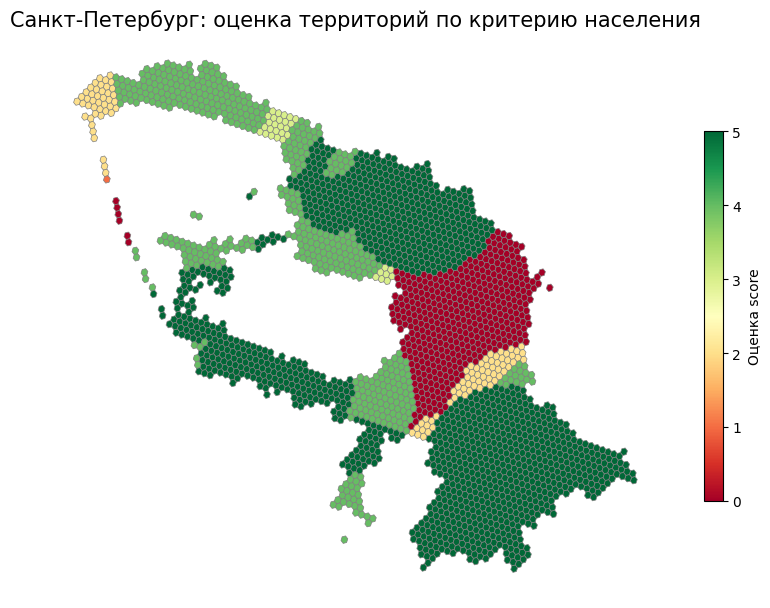

In [10]:
import matplotlib.pyplot as plt

# допустим, ваш GeoDataFrame называется gdf и в нём есть колонки 'geometry' и 'score'
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

gdf_hex.plot(
    column='score',          # раскраска по score
    cmap='RdYlGn',           # палитра от Red → Yellow → Green
    linewidth=0.5,           # толщина границ
    edgecolor='grey',        # цвет границ
    legend=True,             # вывод легенды
    legend_kwds={
        'label': "Оценка score",
        'shrink': 0.6
    },
    ax=ax
)

ax.set_title("Санкт-Петербург: оценка территорий по критерию населения", fontsize=15)
ax.set_axis_off()  # убираем оси

plt.show()



In [11]:
# grid.to_file("grid_population_score.geojson", driver="GeoJSON")

In [12]:
from popframe.method.territory_evaluation import TerritoryEvaluation

evaluation = TerritoryEvaluation(region=region_model)

results = evaluation.evaluate_territory_location(territories_gdf=gdf_hex)
scores_df = pd.DataFrame(results)
scores_df

,territory,score,interpretation,closest_settlement,closest_settlement1,closest_settlement2
0,None,0,Территория находится за границей агломерации,None,None,None
1,None,5,Территория находится внутри или непосредственн...,поселок Левашово,None,None
2,None,7,Территория находится внутри или непосредственн...,поселок Шушары,None,None
3,None,7,Территория находится внутри или непосредственн...,город Колпино,None,None
4,None,1,Территория находится между основными ядрами си...,None,поселок Парголово,поселок Лисий Нос
...,...,...,...,...,...,...
2529,None,0,Территория находится за границей агломерации,None,None,None
2530,None,1,Территория находится между основными ядрами си...,None,поселок Стрельна,поселок Александровская
2531,None,3,Территория находится внутри или непосредственн...,поселок Молодежное,None,None
2532,None,3,Территория находится внутри или непосредственн...,поселок Саперный,None,None


In [13]:
gdf_hex['score_2'] = scores_df['score']
gdf_hex

,geometry,hexagon_id,properties,score,score_2
0,"POLYGON ((30.06574 59.6709, 30.07379 59.67194,...",157558,{},4.0,0
1,"POLYGON ((30.0877 60.08939, 30.09047 60.09382,...",157559,{},5.0,5
2,"POLYGON ((30.37948 59.7927, 30.38759 59.79372,...",157560,{},5.0,7
3,"POLYGON ((30.66727 59.76362, 30.66198 59.76704...",157561,{},5.0,7
4,"POLYGON ((30.24918 60.02467, 30.25198 60.0291,...",157562,{},5.0,1
...,...,...,...,...,...
2529,"POLYGON ((30.45791 60.02272, 30.46608 60.02376...",160087,{},0.0,0
2530,"POLYGON ((30.23231 59.84322, 30.23764 59.83983...",160088,{},0.0,1
2531,"POLYGON ((29.50097 60.20315, 29.49286 60.20206...",160089,{},2.0,3
2532,"POLYGON ((30.74536 59.757, 30.74007 59.76043, ...",160090,{},5.0,3


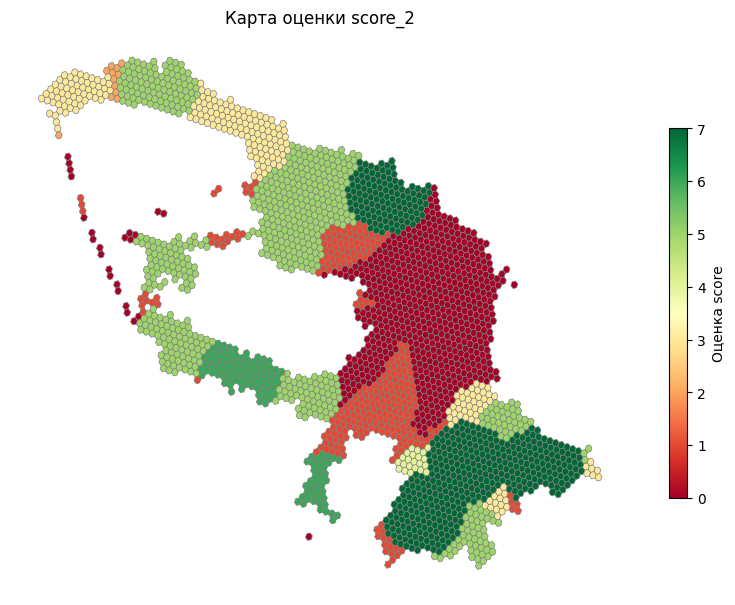

In [14]:
import geopandas as gpd
import matplotlib.pyplot as plt

# допустим, ваш GeoDataFrame называется gdf и в нём есть колонки 'geometry' и 'score'
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

gdf_hex.plot(
    column='score_2',          # раскраска по score
    cmap='RdYlGn',           # палитра от Red → Yellow → Green
    linewidth=0.5,           # толщина границ
    edgecolor='grey',        # цвет границ
    legend=True,             # вывод легенды
    legend_kwds={
        'label': "Оценка score",
        'shrink': 0.6
    },
    ax=ax
)

ax.set_title("Карта оценки score_2")
ax.set_axis_off()  # убираем оси

plt.show()
